<a href="https://colab.research.google.com/github/JANASREE-P/24ADI204_DSV_TEAM4/blob/main/24BAD204_TEAM4_WEEK4_CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

df = pd.read_csv("Spotify_data_cleaned (1).csv")

print(df.shape)
df.head()

Saving Spotify_data_cleaned (1).csv to Spotify_data_cleaned (1).csv
(2826, 20)


,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label,outlier_flag
0,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,15-04-2022,Metal,375706.000000,45.0,0.440000,0.460000,0.0,-14.02,0.0,0.22300,157.740000,1000.0,France,1.0,Island Records,False
1,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,23-02-2016,Rock,373648.952782,55.0,0.521253,0.800000,8.0,-48.26,1.0,0.40464,71.030000,1000.0,Germany,1.0,XL Recordings,False
2,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,12-10-2015,Pop,209484.000000,51.0,0.521253,0.504744,1.0,-34.47,1.0,0.40464,149.000000,1000.0,France,0.0,Warner Music,False
3,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,08-07-2022,Indie,127435.000000,39.0,0.740000,0.180000,10.0,-17.84,0.0,0.30400,155.850000,2000.0,United States,0.0,Columbia,False
4,TRK-A249E0859674,Move each,Devin Schaefer,Detail food,01-01-2018,Rock,373648.952782,36.0,0.910000,0.570000,3.0,-19.61,1.0,0.57400,126.106891,1000.0,Australia,0.0,Warner Music,False


In [3]:
df.describe()

,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count
count,2826.000000,2826.000000,2826.000000,2826.000000,2826.000000,2826.000000,2826.000000,2826.000000,2826.000000,2.826000e+03
mean,260517.220472,47.716883,0.523328,0.505696,5.465621,-27.172877,0.497816,0.402518,126.062050,1.530180e+06
std,100879.640356,15.126332,0.259648,0.270836,3.375081,15.410655,0.495973,0.221462,42.266130,4.161751e+06
min,1000.000000,-1.000000,-0.261235,-0.320243,-1.000000,-54.990000,-1.000000,-0.255798,-0.453505,0.000000e+00
25%,172470.500000,38.000000,0.310000,0.290000,3.000000,-39.987500,0.000000,0.221250,96.205000,1.000000e+03
50%,267753.500000,48.000000,0.521253,0.504744,5.476649,-27.315220,0.590639,0.404640,126.106891,3.000000e+03
75%,358020.250000,55.000000,0.740000,0.720000,8.000000,-14.592500,1.000000,0.583000,159.130000,2.200000e+04
max,419913.000000,100.000000,1.317166,1.327680,12.000000,1.466064,1.000000,1.101850,199.980000,2.000000e+07


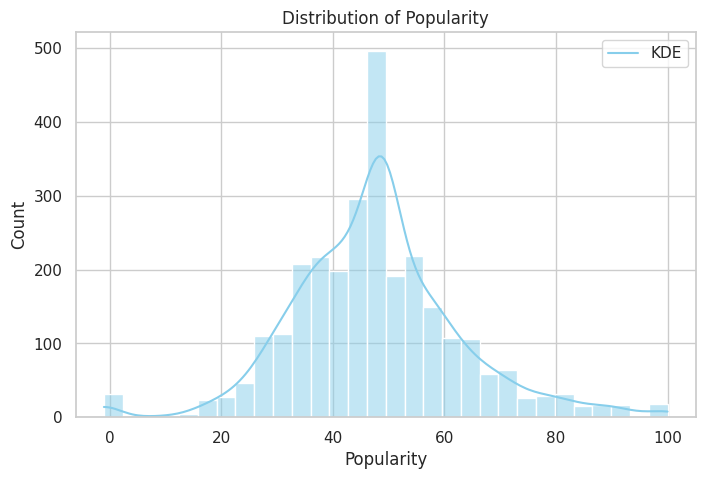

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df['popularity'], bins=30, kde=True, color='skyblue', line_kws={'label':'KDE'}) # Added label for KDE line
plt.title('Distribution of Popularity')
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.legend() # Display legend for KDE line
plt.show()

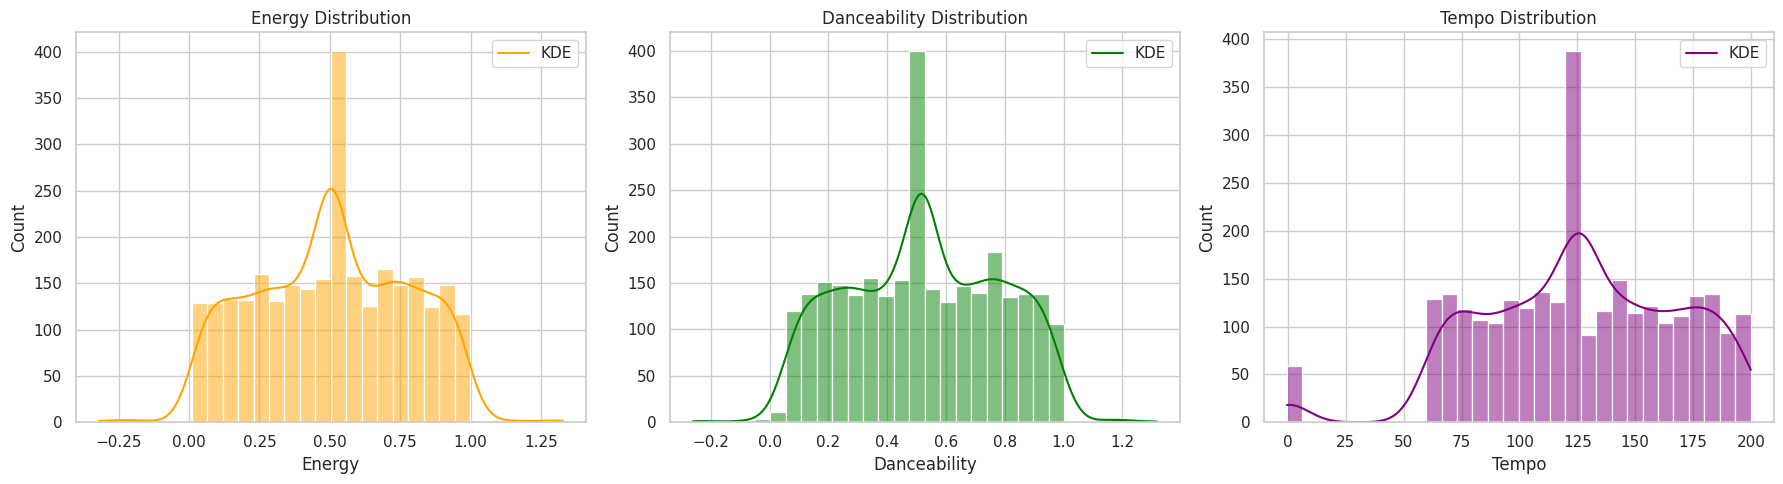

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df['energy'], bins=30, kde=True, color='orange', ax=axes[0], line_kws={'label':'KDE'})
axes[0].set_title('Energy Distribution')
axes[0].set_xlabel('Energy')
axes[0].set_ylabel('Count')
axes[0].legend()

sns.histplot(df['danceability'], bins=30, kde=True, color='green', ax=axes[1], line_kws={'label':'KDE'})
axes[1].set_title('Danceability Distribution')
axes[1].set_xlabel('Danceability')
axes[1].set_ylabel('Count')
axes[1].legend()

sns.histplot(df['tempo'], bins=30, kde=True, color='purple', ax=axes[2], line_kws={'label':'KDE'})
axes[2].set_title('Tempo Distribution')
axes[2].set_xlabel('Tempo')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

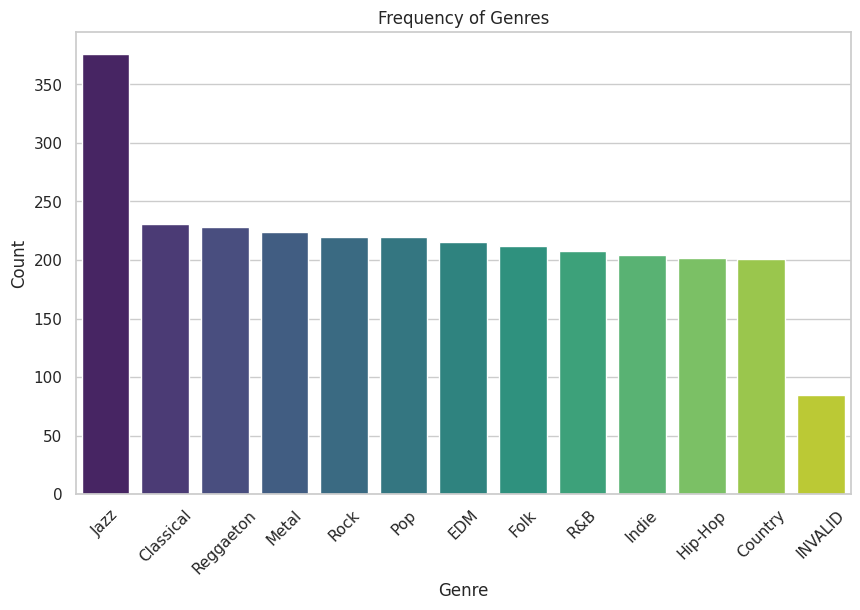

In [17]:
plt.figure(figsize=(10,6))
genre_counts = df['genre'].value_counts()
sns.barplot(x=genre_counts.index, y=genre_counts.values, hue=genre_counts.index, palette='viridis', legend=False) # Addressed FutureWarning by setting hue and legend=False
plt.title('Frequency of Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

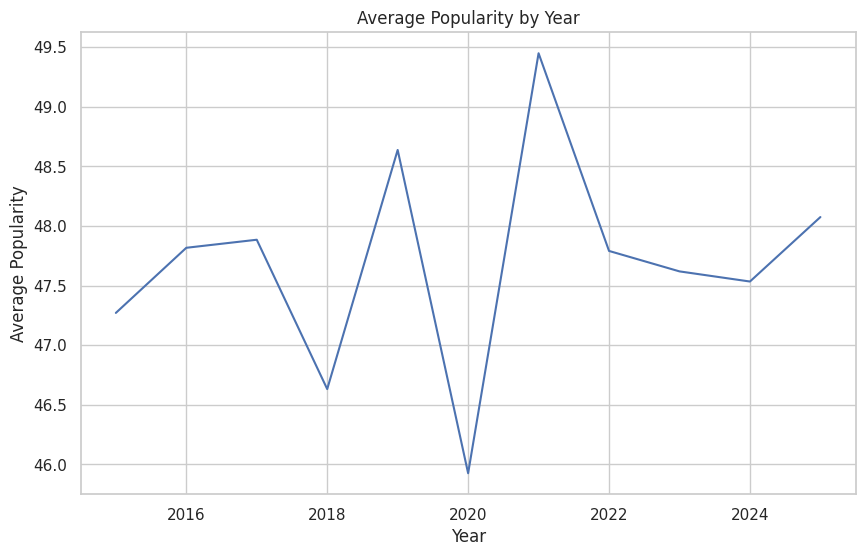

In [18]:
df['release_date'] = pd.to_datetime(df['release_date'], format='%d-%m-%Y', errors='coerce')
df['year'] = df['release_date'].dt.year

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='year', y='popularity', estimator='mean', errorbar=None)
plt.title('Average Popularity by Year')
plt.xlabel('Year')
plt.ylabel('Average Popularity')
plt.show()

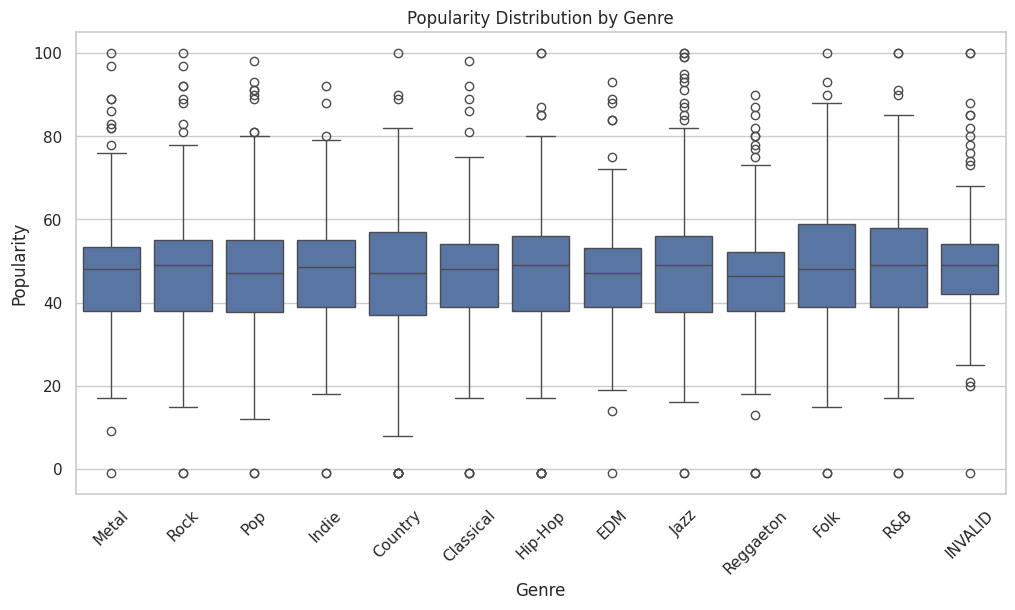

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(x='genre', y='popularity', data=df)
plt.title('Popularity Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('Popularity')
plt.xticks(rotation=45)
plt.show()

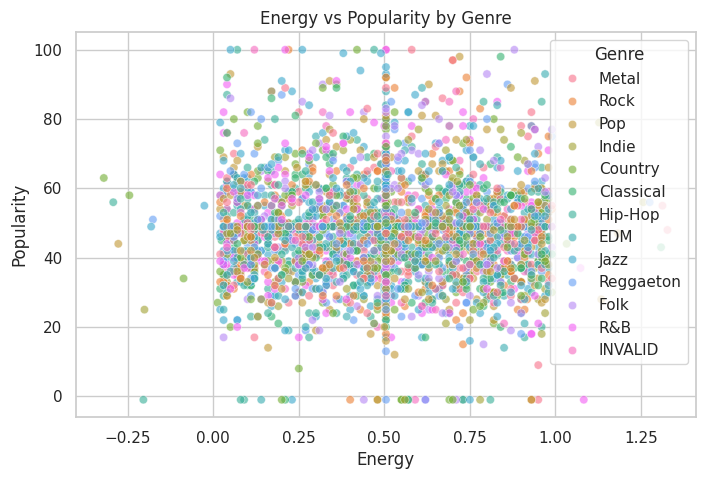

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='energy', y='popularity', hue='genre', data=df, alpha=0.6)
plt.title('Energy vs Popularity by Genre')
plt.xlabel('Energy')
plt.ylabel('Popularity')
plt.legend(title='Genre')
plt.show()

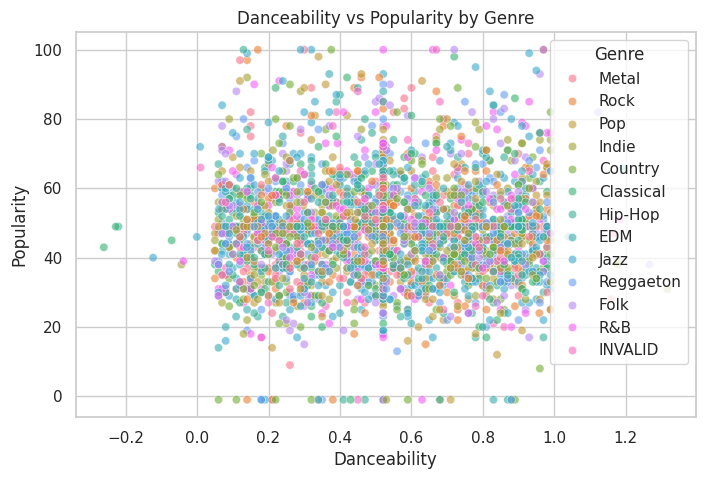

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='danceability', y='popularity', hue='genre', data=df, alpha=0.6)
plt.title('Danceability vs Popularity by Genre')
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.legend(title='Genre')
plt.show()

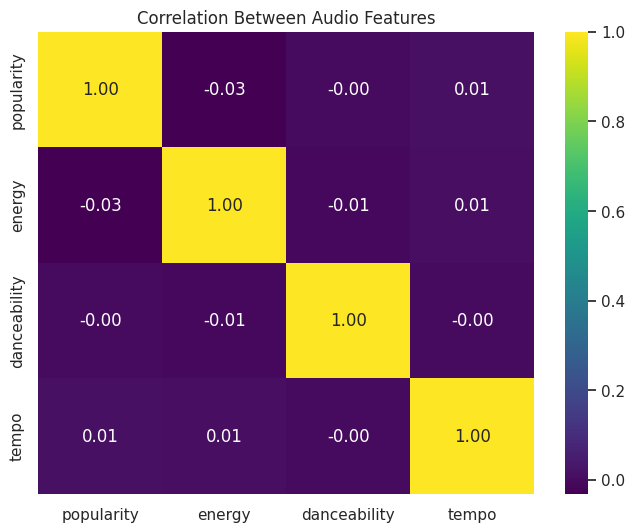

In [22]:
audio_features = ['popularity', 'energy', 'danceability', 'tempo']
plt.figure(figsize=(8,6))
sns.heatmap(df[audio_features].corr(), annot=True, cmap='viridis', fmt=".2f") # Changed colormap to 'viridis'
plt.title('Correlation Between Audio Features')
plt.show()